# Trade the facility-disruption 8-K — short-straddle challenge

**Gator Quant Hacks 2026 · Massive Challenge · Physical facility disruption track**

Disruption 8-Ks (plant fires, outages, force majeure, shutdowns) often read
"temporary / no material impact," yet the options market can still price a large
move. This notebook joins those filings with **NASA FIRMS** thermal labels and
tests a short-premium thesis on the Massive options chain.

## The thesis

> **Filing + `facility_group == brief` → sell premium.** A brief (or absent)
> thermal footprint after a disruption disclosure is a candidate for *implied >
> realized*: the chain overpays for drama that does not persist. Default trade:
> **short ATM straddle**; alternative: **short OTM strangle**. Skip `persistent` and
> `unknown`.

| Tier | What you deliver | Where this notebook gets you |
|---|---|---|
| **Baseline** | Brief disruption events × short straddle (and short OTM strangle) × ~1-month options | Runs end to end from the pre-labeled event JSON |
| **Stretch** | Placebo, decay, persist_days sensitivity, trade costs | Sections 7, 10, 11 and the FIRMS stretch |
| **Sealed window** | Judges rerun on dates you never saw | Final section, one function call |

## How to use this notebook

1. **Run setup** (`setup.ps1` / `setup.sh`) in this folder and pick kernel
   **Python (Gator Quant Hacks .venv)** — same as the Massive 8-K starter.
2. **Keep `USE_CACHED_EVENTS = True`** so the notebook runs from
   `tracks/physical_facility_disruption/data/events/disruption_events.json`
   without a FIRMS key. Document `FIRMS_MAP_KEY` only if you refresh.
3. Section 2 holds the knobs: universe, windows, `TRADE_GROUPS={"brief"}`,
   `BASELINE_BUCKET="1m"`, `STRUCTURES`.
4. Write up the short-straddle finding with uncertainty, placebo, OOS, and
   sensitivity.

## Data

| Dataset | Source | Used for |
|---|---|---|
| Disruption events | Track JSON (Massive 8-K text + geocode + FIRMS) | Filings labeled `brief` / `persistent` / `unknown` |
| Options contracts | Massive `/v3/reference/options/contracts` with `as_of` | Chain on the pre-event session |
| Options aggregates | Massive `/v2/aggs/ticker/O:…` | Leg marks and put-call-parity spot |

API responses cache under `.massive_cache/` next to this notebook.


## Vocabulary

| Term | What it means here |
|---|---|
| **Call** | The right to *buy* 100 shares at the strike, any time before expiry |
| **Put** | The right to *sell* 100 shares at the strike, any time before expiry |
| **Strike** | The fixed price in the contract. `O:STLD260116P00100000` is a $100 put expiring 2026-01-16 |
| **Expiry / DTE** | When the contract dies. `EXPIRY_BUCKETS` picks contracts by days-to-expiry from the pre-event session |
| **Premium** | What the contract costs. Quoted per share — **multiply by 100** for one contract |
| **At the money (ATM)** | Strike closest to the current stock price |
| **Debit / credit** | You pay to open (debit) or you are paid to open (credit). short straddle and OTM strangle open for a **credit** |
| **Short ATM straddle (short straddle)** | Short put with cash set aside to buy 100 shares at the strike if assigned |
| **OTM strangle** | Long 100 shares (here: synthetic) + short OTM call; keep the call premium |
| **Implied move** | ATM call + ATM put, divided by spot — what the chain charges for the event |
| **Realized move** | What the synthetic stock actually did from entry to the exit session |
| **IV crush** | Implied volatility usually *falls* once the news is out; short premium is paid by that |

**Implied vs realized (the heart of this notebook).** Buying options wins when
realized > implied; **selling** wins when realized < implied. The brief-FIRMS
thesis is the sell side: after a disruption filing that leaves no lasting heat
signature, expect the realized path to undershoot the implied move the chain
priced on `t_pre`.

**The stock leg.** OTM strangle needs 100 shares. There is no stock feed here, so
section 6 builds a *synthetic long* from the ATM call/put pair and uses it
wherever a strategy needs shares.


## The strategy library (straddle harvest)

The decay table in the short straddle notebook showed **implied ≫ realized** on FIRMS-`brief`
filings, but short ATM straddles did **not** beat a same-name placebo. That gap is a
**short-volatility** result: the natural instrument is the package the implied move
is built from.

| # | Strategy | Outlook | Legs | Role here |
|---|---|---|---|---|
| 1 | **Short ATM straddle** (default) | Realized move < implied | Sell ATM call + sell ATM put | Primary — direct harvest of overpriced event move |
| 2 | **Short OTM strangle** | Same, defined-er wings | Sell ~5% OTM call + sell ~5% OTM put | Alternate / milder premium |
| — | Short ATM straddle / OTM strangle | Directional short premium | One short option (± stock) | Diagnostics only — under-capture the ATM package |

**Treatment rule.** Trade only when `facility_group ∈ TRADE_GROUPS` (default `{brief}`).

**Risk.** Short straddles / strangles have large left tails (gap risk). This notebook
marks them from OPRA closes for hypothesis testing — not a production margin model.


## Options 101 — short straddle and strangle

### Short ATM straddle

Sell 1 ATM call and 1 ATM put with the same expiry. You collect both premiums. You win
if the stock finishes near the strike (realized move smaller than the combined premium).
You lose if the stock trends or gaps hard either way.

**Construction** Short call K + short put K · **Max gain** sum of premiums · **Max loss**
theoretically large on both sides · **Break-evens** roughly K ± (call + put).

**Facility signal.** `brief` disruption: chain priced a scare; FIRMS shows no lasting heat
→ sell the ATM package that *is* the implied move.

### Short OTM strangle

Sell a call above spot and a put below spot (here: ± `OTM_PCT`). Lower credit than the
straddle, wider break-evens, still short volatility.

OptionsPlaybook timing for short premium is **30–45 DTE** → baseline bucket **`1m`**.


## What you submit

1. **This notebook, or one built on it**, that runs from a clean kernel with only a
   Massive API key (events come from the track JSON by default). The pipeline must
   take a start date and an end date as inputs; judges will call it on a window you
   have not seen (`run_study` in the sealed section).
2. **A write-up of at most two pages**: hypothesis (brief disruptions → sell
   premium), method, results with uncertainty in-sample and out-of-sample, what
   would break it (FIRMS false negatives, small *n*), and how you would trade it.
3. **A parameter-sensitivity check**: expiry bucket, OTM distance, entry session,
   and (stretch) `PERSIST_DAYS`.

| Criterion | Weight | Full marks look like |
|---|---|---|
| Hypothesis and novelty | 30 | Filing + satellite label → short ATM straddle / OTM strangle, not a generic long call |
| Analytical rigor | 30 | Fixed horizons, placebo, OOS, uncertainty, sensitivity |
| Sealed-window replication | 20 | Holds on the judges' window, or you predicted fragility |
| Trade realism | 10 | Entry timing, costs, liquidity |
| Communication | 10 | A write-up a PM could act on; a notebook that runs |


## Requirements and setup

Same environment as the Massive 8-K starter in this folder.

| Install | Minimum | Why |
|---|---|---|
| **Python** | 3.10 | Type-hint syntax |
| **pandas** | 2.2 | Tables |
| **numpy** | 2.0 | Bootstrap |
| **requests** | 2.31 | Massive REST |
| **matplotlib** | 3.8 | Charts |
| **ipykernel** | 6.29 | Jupyter kernel |

You need a **Massive API key** with options access. A **FIRMS map key**
(`FIRMS_MAP_KEY`) is optional and only required if you set `REFRESH_EVENTS = True`
and re-pull satellite labels.

### Setup

```bash
./setup.sh                                            # macOS / Linux
powershell -ExecutionPolicy Bypass -File setup.ps1    # Windows
```

Then open this notebook and choose kernel **Python (Gator Quant Hacks .venv)**.

Put `MASSIVE_API_KEY=…` in `.env` next to this notebook (or rely on
`infrastructure/backtest/.env` / `tracks/physical_facility_disruption/.env`).
Never paste a key into a cell.


In [1]:
# Optional: only if you did NOT run setup.sh / setup.ps1.
# %pip install -q -r requirements.txt


## 1 · API client

Plain `requests` against the REST API. `api_get` caches every response on disk by URL.
Also loads optional `FIRMS_MAP_KEY` aliases for event refresh. Cache lives under
`.massive_cache/` next to this notebook.


In [2]:
import os, json, time, hashlib, re
from dataclasses import dataclass, field
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pandas.tseries.holiday import (AbstractHolidayCalendar, Holiday, nearest_workday, USMartinLutherKingJr,
                                    USPresidentsDay, GoodFriday, USMemorialDay, USLaborDay, USThanksgivingDay)
from pandas.tseries.offsets import CustomBusinessDay

BASE_URL = "https://api.massive.com"
NOTEBOOK_NAMES = (
    "physical-facility-disruption-straddle-challenge.ipynb",
    "physical-facility-disruption-options-challenge.ipynb",
    "gator-quant-hacks-8k-options-challenge.ipynb",
)

# Resolve paths relative to this notebook (VS Code / Cursor often use the repo root as cwd).
NOTEBOOK_DIR = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
    if any((candidate / name).exists() for name in NOTEBOOK_NAMES):
        NOTEBOOK_DIR = candidate
        break
    nested = candidate / "massive" / "gqh-massive-8k-starter"
    if any((nested / name).exists() for name in NOTEBOOK_NAMES):
        NOTEBOOK_DIR = nested
        break
REPO_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "gqh-massive-8k-starter" else NOTEBOOK_DIR
TRACK_DIR = REPO_ROOT / "tracks" / "physical_facility_disruption"


def _read_env_value(path: Path, name: str) -> str:
    if not path.exists():
        return ""
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        if k.strip() == name:
            return v.strip().strip('"').strip("'")
    return ""


def _env_candidates() -> list[Path]:
    return [
        NOTEBOOK_DIR / ".env",
        Path.cwd() / ".env",
        REPO_ROOT / "infrastructure" / "backtest" / ".env",
        REPO_ROOT / "tracks" / "disclosure_advantage" / ".env",
        TRACK_DIR / ".env",
    ]


def load_api_key(name: str = "MASSIVE_API_KEY", *, required: bool = True) -> str:
    """Env var, then starter `.env`, then GQHacks infra / track `.env`, then prompt.

    Accepts MASSIVE_API_KEY / MASSIVE_APP_KEY / POLYGON_API_KEY. Never paste a key into a cell.
    """
    aliases = (name, "MASSIVE_API_KEY", "MASSIVE_APP_KEY", "POLYGON_API_KEY")
    for alias in aliases:
        key = (os.environ.get(alias) or "").strip()
        if key and key != "your-key-here":
            return key

    for env_file in _env_candidates():
        for alias in aliases:
            key = _read_env_value(env_file, alias)
            if key and key != "your-key-here":
                return key

    if not required:
        return ""
    key = getpass(f"{name} (https://massive.com/dashboard/keys): ").strip()
    return key


def load_firms_map_key() -> str:
    """Optional NASA FIRMS map key - only needed when REFRESH_EVENTS=True with satellite re-label."""
    aliases = ("FIRMS_MAP_KEY", "NASA_FIRMS_MAP_KEY", "MAP_KEY")
    for alias in aliases:
        key = (os.environ.get(alias) or "").strip()
        if key and key != "your-key-here":
            return key
    for env_file in _env_candidates():
        for alias in aliases:
            key = _read_env_value(env_file, alias)
            if key and key != "your-key-here":
                return key
    return ""


API_KEY = load_api_key()
FIRMS_MAP_KEY = load_firms_map_key()
SESSION = requests.Session()
SESSION.headers["Authorization"] = f"Bearer {API_KEY}"

CACHE_DIR = NOTEBOOK_DIR / ".massive_cache"
CACHE_DIR.mkdir(exist_ok=True)
os.chdir(NOTEBOOK_DIR)  # keep relative caches / outputs next to the notebook


def api_get(path_or_url: str, params: dict | None = None) -> dict:
    """GET one page from the Massive REST API. Cached on disk by the full URL, so reruns are free."""
    url = path_or_url if path_or_url.startswith("http") else BASE_URL + path_or_url
    full_url = requests.Request("GET", url, params=params).prepare().url
    cache_file = CACHE_DIR / (hashlib.sha1(full_url.encode()).hexdigest() + ".json")
    if cache_file.exists():
        return json.loads(cache_file.read_text())
    for attempt in range(10):
        resp = SESSION.get(full_url, timeout=60)
        if resp.status_code in (429, 500, 502, 503, 504):
            retry_after = resp.headers.get("Retry-After", "")
            time.sleep(float(retry_after) if retry_after.isdigit() else min(2 ** attempt, 20))
            continue
        break
    resp.raise_for_status()
    payload = resp.json()
    cache_file.write_text(json.dumps(payload))
    return payload


def api_get_all(path: str, params: dict | None = None, max_pages: int = 500) -> list[dict]:
    """Follow `next_url` pagination and return every result row."""
    payload = api_get(path, params)
    rows = list(payload.get("results") or [])
    pages = 1
    while payload.get("next_url") and pages < max_pages:
        payload = api_get(payload["next_url"])
        rows.extend(payload.get("results") or [])
        pages += 1
    return rows


print(f"API key loaded (ends {API_KEY[-4:]}); cache at {CACHE_DIR.resolve()}")
print(f"FIRMS_MAP_KEY {'loaded (ends ' + FIRMS_MAP_KEY[-4:] + ')' if FIRMS_MAP_KEY else 'not set (cached events still work)'}")
print(f"TRACK_DIR = {TRACK_DIR}")


API key loaded (ends jNOD); cache at C:\Users\kprsa\Documents\CodingProjects\GQHacks\massive\gqh-massive-8k-starter\.massive_cache
FIRMS_MAP_KEY loaded (ends 1f75)
TRACK_DIR = c:\Users\kprsa\Documents\CodingProjects\GQHacks\tracks\physical_facility_disruption


## 2 · Configuration

Everything a team is allowed to change lives in this cell. Horizons are **fixed**
so results are comparable. Events come from the track's pre-labeled JSON by default
(`USE_CACHED_EVENTS = True`) — no `EVENT_TAG=cfo_appointment` here.

- **`TRADE_GROUPS`**: which `facility_group` labels to trade (default `{brief}`).
- **`STRUCTURES`**: strategies on the scoreboard — short ATM straddle and OTM strangle.
- **`BASELINE_BUCKET = "1m"`**: ~4 weeks to expiry, matching the track's `expiry_weeks=4`.
- **Three windows.** In-sample research, recent out-of-sample, sealed holdout for judges.


In [3]:
# ---- Facility disruption events (pre-labeled JSON; no CFO taxonomy tag) ----------------
USE_CACHED_EVENTS = True
REFRESH_EVENTS = False          # keep False; refresh via fetch_disruption_events.py + --firms
_LOCAL_EVENTS = NOTEBOOK_DIR / "data" / "events" / "disruption_events.json"
_TRACK_EVENTS = TRACK_DIR / "data" / "events" / "disruption_events.json"
EVENTS_PATH = _LOCAL_EVENTS if _LOCAL_EVENTS.exists() else _TRACK_EVENTS
PERSIST_DAYS = 3                # FIRMS brief vs persistent threshold (days)
TRADE_GROUPS = {"brief"}        # sell premium only on these facility_group labels

# ---- Windows (aligned with a 2019+ Massive+FIRMS refresh) ------------------------------
STUDY_START, STUDY_END = "2019-01-01", "2024-12-31"      # in-sample
OOS_START, OOS_END = "2025-01-01", "2025-12-31"          # out-of-sample
HOLDOUT_START, HOLDOUT_END = "2026-01-01", "2026-06-30"  # sealed: judges change these and flip RUN_HOLDOUT

# ---- Universe: industrials / steel / chem / refining / mining (must match fetch --symbols)
FACILITY_UNIVERSE = """
STLD PSX DOW FCX X NUE CLF AA LYB MOS CF FMC EMN APD MLM VMC
NEM SCCO VALE RIO BHP MPC VLO PBF DVN OXY HES COP CVX XOM
RS CMC MT TX CENX WLK CE HUN CTVA ADM BG
BTU CBT GPK INGR IP OLN PKG TROX DINO ARCH WOR HON EXP ALB
""".split()
assert len(FACILITY_UNIVERSE) == len(set(FACILITY_UNIVERSE))

# ---- Expiry buckets: name -> (min, max, target) calendar days to expiry from t_pre ------
EXPIRY_BUCKETS = {
    "1m":   (21, 45, 30),   # ~4 weeks - track default
    "2m":   (46, 80, 60),
    "3-6m": (90, 180, 120),
}
BASELINE_BUCKET = "1m"

# ---- Fixed horizons (sessions after the filing session). Do not change. ----------------
HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]

# ---- Structures scored on the board (engine still knows the full starter set) ----------
STRUCTURES = ["short_atm_straddle", "short_otm_strangle"]
DIAGNOSTIC_STRUCTURES = ["cash_secured_put", "covered_call", "short_atm_put"]

# ---- Strategy parameters ---------------------------------------------------------------
OTM_PCT = 0.05
OTM_GRID = [0.03, 0.05, 0.10]
ENTRY = "post"              # "post": close of filing session; "pre": close of session before
RISK_FREE = 0.04

# ---- Mechanics -------------------------------------------------------------------------
STRIKE_WINDOW = 0.25
MAX_STALE_SESSIONS = 3
MAX_EVENTS = None           # e.g. 15 for a smoke test; None = all

# ---- Stretch toggles -------------------------------------------------------------------
RUN_PLACEBO = True
N_PLACEBO = 80              # ordinary-day control for short-vol structures
PLACEBO_GAP_DAYS = 30
RUN_HOLDOUT = False
FETCH_ACCEPTANCE_TIMES = False
SEC_USER_AGENT = "GatorQuantHacks team-name your@email.edu"

assert OTM_PCT in OTM_GRID and BASELINE_BUCKET in EXPIRY_BUCKETS and ENTRY in ("pre", "post")
assert TRADE_GROUPS and STRUCTURES

for _name in ("STUDY_START", "STUDY_END", "OOS_START", "OOS_END", "HOLDOUT_START", "HOLDOUT_END"):
    try:
        pd.Timestamp(globals()[_name])
    except ValueError:
        raise ValueError(f"{_name} = {globals()[_name]!r} is not a real date") from None
assert STUDY_START < STUDY_END and OOS_START < OOS_END and HOLDOUT_START < HOLDOUT_END

print(f"Universe {len(FACILITY_UNIVERSE)} names - trade_groups={TRADE_GROUPS} - "
      f"structures={STRUCTURES} - baseline={BASELINE_BUCKET} - persist_days={PERSIST_DAYS}")
print(f"Events path: {EVENTS_PATH} (exists={EVENTS_PATH.exists()})")


Universe 55 names - trade_groups={'brief'} - structures=['short_atm_straddle', 'short_otm_strangle'] - baseline=1m - persist_days=3
Events path: c:\Users\kprsa\Documents\CodingProjects\GQHacks\tracks\physical_facility_disruption\data\events\disruption_events.json (exists=True)


### Disruption vocabulary and facility groups

Instead of the 119-tag disclosure taxonomy, this notebook filters 8-K text for
physical facility language and joins NASA FIRMS thermal persistence.

| `disruption_type` | Typical text cues |
|---|---|
| `facility_fire` | fire at plant / mill / warehouse |
| `explosion` | explosion, blast |
| `plant_outage` | outage, power outage |
| `plant_shutdown` | shutdown, suspended, halted, idled |
| `force_majeure` | force majeure + facility / production |
| `chemical_release` | chemical / gas release, spill, leak |

| `facility_group` | Meaning | Trade? |
|---|---|---|
| **`brief`** | No lasting thermal anomaly (or cleared before `PERSIST_DAYS`) | **Yes — sell premium** |
| **`persistent`** | Anomaly still on after `PERSIST_DAYS` | No (control / skip) |
| **`unknown`** | No site / no satellite coverage | No (exclude) |


In [4]:
FACILITY_GROUP_TABLE = pd.DataFrame([
    {"facility_group": "brief", "rule": f"no lasting anomaly or clears before {PERSIST_DAYS}d", "action": "sell ATM straddle / OTM strangle"},
    {"facility_group": "persistent", "rule": f"anomaly_persist_days >= {PERSIST_DAYS}", "action": "skip (control)"},
    {"facility_group": "unknown", "rule": "missing site or satellite coverage", "action": "skip"},
])
display(FACILITY_GROUP_TABLE)


,facility_group,rule,action
0,brief,no lasting anomaly or clears before 3d,sell ATM straddle / OTM strangle
1,persistent,anomaly_persist_days >= 3,skip (control)
2,unknown,missing site or satellite coverage,skip


## 3 · A trading calendar without a stock feed

Every horizon is counted in sessions. Weekdays minus NYSE full-day closures
(Good Friday closed; Columbus / Veterans Day open; Carter mourning day 2025-01-09).


In [5]:
class NYSEHolidays(AbstractHolidayCalendar):
    """NYSE full-day closures. Differs from the federal calendar: Good Friday closed, Columbus and
    Veterans Day open, no observance when New Year's Day falls on a Saturday."""
    rules = [
        Holiday("New Year's Day", month=1, day=1,
                observance=lambda d: d + pd.Timedelta(days=1) if d.weekday() == 6 else d),
        USMartinLutherKingJr, USPresidentsDay, GoodFriday, USMemorialDay,
        Holiday("Juneteenth", month=6, day=19, start_date="2022-01-01", observance=nearest_workday),
        Holiday("Independence Day", month=7, day=4, observance=nearest_workday),
        USLaborDay, USThanksgivingDay,
        Holiday("Christmas Day", month=12, day=25, observance=nearest_workday),
        Holiday("National day of mourning, President Carter", year=2025, month=1, day=9),
    ]


def trading_sessions(start, end) -> pd.DatetimeIndex:
    holidays = NYSEHolidays().holidays(pd.Timestamp(start) - pd.Timedelta(days=7), pd.Timestamp(end) + pd.Timedelta(days=7))
    return pd.bdate_range(start, end, freq=CustomBusinessDay(holidays=holidays))


CAL = trading_sessions("2019-06-01", "2027-12-31")
TODAY = pd.Timestamp.today().normalize()
LAST_SESSION = CAL[CAL.searchsorted(TODAY, side="right") - 1]


def session_on_or_after(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left")]


def session_before(day) -> pd.Timestamp:
    return CAL[CAL.searchsorted(pd.Timestamp(day), side="left") - 1]


def sessions_between(a, b) -> int:
    """Number of sessions strictly after `a` up to and including `b`."""
    return int(CAL.searchsorted(pd.Timestamp(b), side="right") - CAL.searchsorted(pd.Timestamp(a), side="right"))


print(f"{len(CAL)} sessions in the calendar; last completed session {LAST_SESSION.date()}. "
      f"Sessions per year: " + ", ".join(f"{y}: {((CAL.year == y)).sum()}" for y in range(2020, 2027)))


2158 sessions in the calendar; last completed session 2026-10-02. Sessions per year: 2020: 253, 2021: 252, 2022: 251, 2023: 250, 2024: 252, 2025: 250, 2026: 251


## 4 · Events

By default this cell loads the track's pre-labeled `disruption_events.json` (already
has `facility_group` from FIRMS). It filters to `TRADE_GROUPS`, `FACILITY_UNIVERSE`,
and the requested window, then attaches `t_0` / `t_pre` like the Massive starter.

Set `REFRESH_EVENTS = True` only if you want a fresh Massive disclosures / 8-K text
pull; full FIRMS re-label still needs `FIRMS_MAP_KEY` and the track scripts.


In [6]:
# Case-insensitive phrases that mark a physical facility disruption (from massive_disruptions.py).
_DISRUPTION_RE = re.compile(
    r"""
    \b(
        (?:facility|plant|refinery|mill|warehouse|factory|mine|terminal|pipeline|smelter|foundry)
        .{0,60}?
        (?:fire|explosion|blast|outage|shutdown|shut\s*down|destroyed|damaged|idled)
      | (?:fire|explosion|blast|outage|shutdown|shut\s*down)
        .{0,60}?
        (?:facility|plant|refinery|mill|warehouse|factory|mine|terminal|pipeline|smelter|foundry|operations?)
      | (?:industrial|warehouse|plant|mill|refinery)\s+fire
      | fire\s+at\s+the\s+(?:company|corporation|issuer)'?s?
      | explosion\s+at\s+the\s+(?:company|corporation|issuer)'?s?
      | force\s+majeure.{0,60}?(?:facility|plant|refinery|mill|mine|operations|production)
      | (?:facility|plant|refinery|mill|mine|operations|production).{0,60}?force\s+majeure
      | temporary\s+(?:suspension|halt|closure|shutdown)
      | (?:operations?|production)\s+(?:suspended|halted|idled|curtailed)
      | power\s+outage
      | gas\s+leak
      | chemical\s+(?:release|spill|leak)
    )\b
    """,
    re.IGNORECASE | re.VERBOSE,
)

_DISRUPTION_TYPE_PATTERNS = [
    ("facility_fire", re.compile(r"\bfire\b", re.I)),
    ("explosion", re.compile(r"\b(explosion|blast)\b", re.I)),
    ("plant_outage", re.compile(r"\b(outage|power\s+outage)\b", re.I)),
    ("plant_shutdown", re.compile(r"\b(shut\s*down|shutdown|suspended|halted|idled)\b", re.I)),
    ("force_majeure", re.compile(r"\bforce\s+majeure\b", re.I)),
    ("chemical_release", re.compile(r"\b(chemical|gas)\s+(release|spill|leak)\b", re.I)),
]


def normalize_ticker(t) -> str | None:
    if not isinstance(t, str) or not t.strip():
        return None
    return t.strip().upper().replace("/", ".")


def is_disruption_text(text: str | None) -> bool:
    if not text:
        return False
    return bool(_DISRUPTION_RE.search(text))


def classify_disruption_type(text: str | None) -> str | None:
    if not text:
        return None
    for label, pattern in _DISRUPTION_TYPE_PATTERNS:
        if pattern.search(text):
            return label
    return "physical_disruption" if is_disruption_text(text) else None


def assign_facility_group(
    *,
    anomaly_detected: bool | None,
    anomaly_persist_days: int | None,
    persist_days: int = 3,
    has_site: bool = True,
    has_satellite_coverage: bool = True,
) -> str:
    """Map raw anomaly stats to brief | persistent | unknown (matches facility_groups.py)."""
    if persist_days < 1:
        raise ValueError("persist_days must be >= 1")
    if not has_site or not has_satellite_coverage:
        return "unknown"
    if anomaly_detected is None:
        return "unknown"
    if not anomaly_detected:
        return "brief"
    days = 0 if anomaly_persist_days is None else int(anomaly_persist_days)
    if days < 0:
        return "unknown"
    if days >= persist_days:
        return "persistent"
    return "brief"


def load_cached_events(path: Path = EVENTS_PATH) -> pd.DataFrame:
    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    rows = payload.get("events", payload if isinstance(payload, list) else [])
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["ticker"] = df["ticker"].map(normalize_ticker)
    df["filing_date"] = pd.to_datetime(df["filing_date"])
    if "facility_group" not in df.columns or df["facility_group"].isna().any():
        df["facility_group"] = [
            assign_facility_group(
                anomaly_detected=row.get("anomaly_detected"),
                anomaly_persist_days=row.get("anomaly_persist_days"),
                persist_days=PERSIST_DAYS,
                has_site=bool(row.get("has_site", row.get("site_lat") is not None)),
                has_satellite_coverage=bool(row.get("has_satellite_coverage", True)),
            )
            for row in df.to_dict("records")
        ]
    return df


def refresh_events_from_massive(universe: list[str], start: str, end: str) -> pd.DataFrame:
    """Optional fallback: pull Massive 8-K disclosures and keep disruption-like text.
    Does not re-run FIRMS; facility_group stays unknown unless already present."""
    rows = api_get_all("/stocks/filings/8-K/vX/disclosures", {
        "filing_date.gte": start, "filing_date.lte": end, "limit": 1000, "sort": "filing_date.asc",
    })
    raw = pd.DataFrame(rows)
    if raw.empty:
        return raw
    ex = raw.explode("tickers").rename(columns={"tickers": "ticker"})
    ex["ticker"] = ex["ticker"].map(normalize_ticker)
    ex = ex[ex["ticker"].isin(universe)].copy()
    text_col = "supporting_text" if "supporting_text" in ex.columns else None
    if text_col:
        ex = ex[ex[text_col].map(is_disruption_text)].copy()
        ex["disruption_type"] = ex[text_col].map(classify_disruption_type)
    ex["filing_date"] = pd.to_datetime(ex["filing_date"])
    ex["facility_group"] = "unknown"
    ex["has_site"] = False
    keep = [c for c in ["ticker", "filing_date", "accession_number", "filing_url", "supporting_text",
                        "disruption_type", "facility_group", "has_site", "anomaly_detected",
                        "anomaly_persist_days", "has_satellite_coverage", "items_text", "match_snippet"]
            if c in ex.columns or c in ("facility_group", "has_site", "disruption_type")]
    for c in ("facility_group", "has_site", "disruption_type"):
        if c not in ex.columns:
            ex[c] = {"facility_group": "unknown", "has_site": False, "disruption_type": None}[c]
    return ex.drop_duplicates(["ticker", "filing_date"]).reset_index(drop=True)


def build_events_from_cache(
    start: str,
    end: str,
    universe: list[str],
    *,
    trade_groups: set[str] | None = None,
    path: Path = EVENTS_PATH,
    persist_days: int | None = None,
) -> pd.DataFrame:
    """One row per (ticker, filing date) in universe/window with t_0 / t_pre sessions."""
    trade_groups = trade_groups if trade_groups is not None else TRADE_GROUPS
    persist_days = PERSIST_DAYS if persist_days is None else persist_days

    if REFRESH_EVENTS and not USE_CACHED_EVENTS:
        raw = refresh_events_from_massive(universe, start, end)
        print(f"REFRESH_EVENTS: {len(raw)} disruption-like disclosures from Massive, {start}..{end}")
    else:
        raw = load_cached_events(path)
        print(f"Loaded {len(raw)} cached disruption events from {path}")

    if raw.empty:
        return raw

    if persist_days != PERSIST_DAYS or raw["facility_group"].isna().any():
        raw = raw.copy()
        raw["facility_group"] = [
            assign_facility_group(
                anomaly_detected=row.get("anomaly_detected"),
                anomaly_persist_days=row.get("anomaly_persist_days"),
                persist_days=persist_days,
                has_site=bool(row.get("has_site", row.get("site_lat") is not None)),
                has_satellite_coverage=bool(row.get("has_satellite_coverage", True)),
            )
            for row in raw.to_dict("records")
        ]

    ev = raw.copy()
    ev = ev[ev["ticker"].isin(universe)]
    ev = ev[(ev["filing_date"] >= pd.Timestamp(start)) & (ev["filing_date"] <= pd.Timestamp(end))]
    before_groups = len(ev)
    ev = ev[ev["facility_group"].isin(trade_groups)].copy()
    ev = (ev.sort_values(["ticker", "filing_date"])
            .drop_duplicates(["ticker", "filing_date"])
            .reset_index(drop=True))
    ev["t_0"] = ev["filing_date"].map(session_on_or_after)
    ev["t_pre"] = ev["t_0"].map(session_before)
    ev["event_date"] = ev["filing_date"]
    ev["days_since_prev_event"] = ev.groupby("ticker")["filing_date"].diff().dt.days
    print(f"{before_groups} in universe/window -> {len(ev)} after trade_groups={trade_groups}")
    return ev


events = build_events_from_cache(STUDY_START, STUDY_END, FACILITY_UNIVERSE)
if MAX_EVENTS:
    events = events.head(MAX_EVENTS).copy()

# Counts by facility_group on the full cached file (pre trade_groups filter) for context.
_all = load_cached_events(EVENTS_PATH)
if not _all.empty:
    _win = _all[(_all.filing_date >= pd.Timestamp(STUDY_START)) & (_all.filing_date <= pd.Timestamp(STUDY_END))
                & (_all.ticker.isin(FACILITY_UNIVERSE))]
    print("facility_group counts in study window (pre trade filter):")
    display(_win.groupby("facility_group").size().rename("events").to_frame().T)

print(f"{len(events)} in-sample tradeable events across {events.ticker.nunique() if len(events) else 0} tickers; "
      f"{(events.filing_date != events.t_0).sum() if len(events) else 0} filed on a non-session day")
if len(events):
    display(events.groupby(events.filing_date.dt.year).size().rename("events").to_frame().T)
    cols = [c for c in ["ticker", "filing_date", "t_pre", "t_0", "facility_group", "disruption_type", "match_snippet"] if c in events.columns]
    with pd.option_context("display.max_colwidth", 90):
        display(events[cols].head(10))


Loaded 45 cached disruption events from c:\Users\kprsa\Documents\CodingProjects\GQHacks\tracks\physical_facility_disruption\data\events\disruption_events.json
31 in universe/window -> 24 after trade_groups={'brief'}
facility_group counts in study window (pre trade filter):


facility_group,brief,persistent,unknown
events,24,1,6


24 in-sample tradeable events across 18 tickers; 0 filed on a non-session day


filing_date,2020,2021,2022,2023,2024
events,8,5,1,5,5


,ticker,filing_date,t_pre,t_0,facility_group,disruption_type,match_snippet
0,AA,2021-12-13,2021-12-10,2021-12-13,brief,plant_shutdown,ely. The Smelter has been fully curtailed since 2015. The Company's decision to perman...
1,AA,2023-03-16,2023-03-15,2023-03-16,brief,plant_shutdown,ely. The Smelter has been fully curtailed since 2020. The Company's decision to perman...
2,BTU,2020-10-05,2020-10-02,2020-10-05,brief,physical_disruption,"following the completion of its recent H-3 panel longwall move, the Company is tempora..."
3,CBT,2020-09-30,2020-09-29,2020-09-30,brief,plant_shutdown,"iately, to cease manufacturing lignite-based activated carbon at its production facili..."
4,CE,2020-07-28,2020-07-27,2020-07-28,brief,plant_shutdown,"on-cash accelerated depreciation of fixed asset costs, and approximately $15-25 millio..."
5,CE,2023-10-31,2023-10-30,2023-10-31,brief,plant_shutdown,non-cash accelerated depreciation of fixed asset costs and approximately $35-40 millio...
6,CE,2024-02-29,2024-02-28,2024-02-29,brief,plant_shutdown,non-cash accelerated depreciation of fixed asset costs and approximately $20-25 millio...
7,CENX,2022-06-22,2022-06-21,2022-06-22,brief,physical_disruption,"Aluminum Company (the ""Company"") issued a press release announcing that it will tempor..."
8,CMC,2021-09-30,2021-09-29,2021-09-30,brief,plant_shutdown,tely 95 acres of real property in Rancho Cucamonga on which TAMCO's idled steel mill a...
9,GPK,2021-02-24,2021-02-23,2021-02-24,brief,physical_disruption,esulting power disruptions and natural gas curtailments. Both mills experienced unplan...


## 5 · The option chain, and the stock price hidden inside it

For each event, one request to the contracts endpoint with `as_of = t_pre` returns
every contract that existed that day. Spot is recovered from put-call parity on the
near-dated ATM pair; expiry is chosen inside each `EXPIRY_BUCKETS` window.


In [7]:
def option_bars(opt_ticker: str, start, end) -> pd.DataFrame:
    """Daily bars for one contract: index = session, columns close and volume. Only sessions where it traded."""
    rows = api_get_all(f"/v2/aggs/ticker/{opt_ticker}/range/1/day/{pd.Timestamp(start):%Y-%m-%d}/{pd.Timestamp(end):%Y-%m-%d}",
                       {"adjusted": "false", "sort": "asc", "limit": 50000})
    if not rows:
        return pd.DataFrame(columns=["close", "volume"], index=pd.DatetimeIndex([], name="session"))
    idx = (pd.to_datetime([r["t"] for r in rows], unit="ms", utc=True)
             .tz_convert("America/New_York").normalize().tz_localize(None))
    return pd.DataFrame({"close": [float(r["c"]) for r in rows], "volume": [float(r.get("v") or 0) for r in rows]},
                        index=pd.DatetimeIndex(idx, name="session"))


def fetch_chain(ticker: str, as_of: pd.Timestamp, dte_lo: int, dte_hi: int) -> pd.DataFrame:
    """Every standard contract that existed on `as_of` with an expiry `dte_lo`..`dte_hi` days out."""
    rows = api_get_all("/v3/reference/options/contracts", {
        "underlying_ticker": ticker, "as_of": as_of.strftime("%Y-%m-%d"),
        "expiration_date.gte": (as_of + pd.Timedelta(days=dte_lo)).strftime("%Y-%m-%d"),
        "expiration_date.lte": (as_of + pd.Timedelta(days=dte_hi)).strftime("%Y-%m-%d"),
        "limit": 1000,
    })
    chain = pd.DataFrame(rows)
    if chain.empty:
        return chain
    if "shares_per_contract" in chain:
        chain = chain[chain["shares_per_contract"].fillna(100) == 100]
    chain = chain[["ticker", "contract_type", "strike_price", "expiration_date"]].copy()
    chain["expiration_date"] = pd.to_datetime(chain["expiration_date"])
    chain["dte"] = (chain["expiration_date"] - as_of).dt.days
    chain["strike_price"] = chain["strike_price"].astype(float)
    return chain.reset_index(drop=True)


def paired_strikes(e: pd.DataFrame) -> np.ndarray:
    both = e.groupby("strike_price")["contract_type"].nunique()
    return both[both == 2].index.to_numpy(dtype=float)


def contract(e: pd.DataFrame, strike: float, kind: str) -> str:
    return e[(e.strike_price == strike) & (e.contract_type == kind)]["ticker"].iloc[0]


def last_close_on_or_before(opt_ticker: str, day: pd.Timestamp, lookback_days: int = 7) -> float | None:
    bars = option_bars(opt_ticker, day - pd.Timedelta(days=lookback_days), day)
    return float(bars["close"].iloc[-1]) if len(bars) else None


def locate_spot(chain: pd.DataFrame, day: pd.Timestamp, max_iter: int = 8) -> dict | None:
    """Recover the stock price on `day` from the option chain alone, via put-call parity."""
    near = chain[chain.dte >= 3]
    if near.empty:
        return None
    near = near[near.dte == near.dte.min()]
    strikes = paired_strikes(near)
    if len(strikes) < 3:
        return None
    T = near.dte.iloc[0] / 365
    k, tried, est = float(np.median(strikes)), set(), None
    k = strikes[np.abs(strikes - k).argmin()]
    for _ in range(max_iter):
        tried.add(k)
        c = last_close_on_or_before(contract(near, k, "call"), day)
        p = last_close_on_or_before(contract(near, k, "put"), day)
        if c is None or p is None:
            rest = [s for s in strikes if s not in tried]
            if not rest:
                break
            k = rest[int(np.abs(np.array(rest) - k).argmin())]
            continue
        est = k * np.exp(-RISK_FREE * T) + c - p
        k_new = strikes[np.abs(strikes - est).argmin()]
        if k_new == k or k_new in tried:
            break
        k = k_new
    if est is None:
        return None
    return {"spot": float(est), "strike": float(k), "expiry": near.expiration_date.iloc[0], "dte": int(near.dte.iloc[0])}


def pick_expiry(chain: pd.DataFrame, lo: int, hi: int, target: int) -> pd.Timestamp | None:
    cand = chain[(chain.dte >= lo) & (chain.dte <= hi)]
    if cand.empty:
        return None
    dte_of = cand.groupby("expiration_date")["dte"].first()
    ok = [x for x, g in cand.groupby("expiration_date") if len(paired_strikes(g)) >= 3]
    if not ok:
        return None
    return min(ok, key=lambda x: abs(dte_of[x] - target))


def select_strikes(e: pd.DataFrame, spot: float, otm_pcts: list[float]) -> dict[str, float] | None:
    both = paired_strikes(e)
    both = both[(both >= spot * (1 - STRIKE_WINDOW)) & (both <= spot * (1 + STRIKE_WINDOW))]
    if len(both) == 0:
        return None
    calls = np.sort(e.loc[e.contract_type == "call", "strike_price"].unique())
    puts = np.sort(e.loc[e.contract_type == "put", "strike_price"].unique())
    out = {"K": float(both[np.abs(both - spot).argmin()])}
    for pct in otm_pcts:
        up, dn = calls[calls >= spot * (1 + pct)], puts[puts <= spot * (1 - pct)]
        out[f"U{pct}"] = float(up.min()) if len(up) else float(calls.max())
        out[f"L{pct}"] = float(dn.max()) if len(dn) else float(puts.min())
    return out


### Pricing every event

`price_events` runs the chain steps for each event and bucket and returns
`PricedEvent` objects. `summarize_priced` flattens a first look; `abs_spot_gap`
checks near-dated parity spot vs this bucket's ATM pair.


In [8]:
@dataclass
class Leg:
    ticker: str
    kind: str                 # "call" or "put"
    strike: float
    bars: pd.DataFrame

    def mark(self, day: pd.Timestamp) -> float:
        b = self.bars.loc[: pd.Timestamp(day)]
        if b.empty or sessions_between(b.index[-1], day) > MAX_STALE_SESSIONS:
            return np.nan
        return float(b["close"].iloc[-1])

    def volume_on(self, day: pd.Timestamp) -> float:
        return float(self.bars["volume"].get(pd.Timestamp(day), 0.0))


@dataclass
class PricedEvent:
    ticker: str
    event_date: pd.Timestamp
    t_pre: pd.Timestamp
    t_0: pd.Timestamp
    bucket: str
    expiry: pd.Timestamp
    expiry_session: pd.Timestamp
    spot_pre: float
    strikes: dict[str, float]
    legs: dict[str, Leg]

    def marks(self, day) -> dict[str, float]:
        return {name: leg.mark(day) for name, leg in self.legs.items()}

    def synthetic_spot(self, day, m: dict[str, float] | None = None) -> float:
        m = m if m is not None else self.marks(day)
        T = max((self.expiry - pd.Timestamp(day)).days, 0) / 365
        return self.strikes["K"] * np.exp(-RISK_FREE * T) + m["C_K"] - m["P_K"]


def price_event(ticker: str, t_pre: pd.Timestamp, t_0: pd.Timestamp, event_date: pd.Timestamp,
                buckets: dict, otm_pcts: list[float]) -> tuple[list[PricedEvent], list[str]]:
    dte_hi = max(b[1] for b in buckets.values())
    chain = fetch_chain(ticker, t_pre, 2, dte_hi)
    if chain.empty:
        return [], ["no option chain as of the pre-event session"]
    loc = locate_spot(chain, t_pre)
    if loc is None:
        return [], ["could not recover spot from the chain (no liquid near-dated pair)"]
    priced, notes = [], []
    for name, (lo, hi, target) in buckets.items():
        expiry = pick_expiry(chain, lo, hi, target)
        if expiry is None:
            notes.append(f"{name}: no expiry {lo}-{hi} days out")
            continue
        e = chain[chain.expiration_date == expiry]
        strikes = select_strikes(e, loc["spot"], otm_pcts)
        if strikes is None:
            notes.append(f"{name}: no paired strikes near spot")
            continue
        wanted = {"C_K": ("call", strikes["K"]), "P_K": ("put", strikes["K"])}
        for pct in otm_pcts:
            wanted[f"C_U{pct}"] = ("call", strikes[f"U{pct}"])
            wanted[f"P_L{pct}"] = ("put", strikes[f"L{pct}"])
        legs = {}
        for key, (kind, k) in wanted.items():
            tk = contract(e, k, kind)
            legs[key] = Leg(tk, kind, k, option_bars(tk, t_pre - pd.Timedelta(days=10), expiry))
        pe = PricedEvent(ticker, event_date, t_pre, t_0, name, expiry, CAL[CAL.searchsorted(expiry, side="right") - 1],
                         loc["spot"], strikes, legs)
        if np.isnan(pe.legs["C_K"].mark(t_pre)) or np.isnan(pe.legs["P_K"].mark(t_pre)):
            notes.append(f"{name}: ATM pair did not trade on or near the pre-event session")
            continue
        priced.append(pe)
    return priced, notes


def price_events(ev: pd.DataFrame, buckets: dict = None, otm_pcts: list[float] = None, label: str = "events") -> tuple[list[PricedEvent], pd.DataFrame]:
    buckets = buckets or EXPIRY_BUCKETS
    otm_pcts = otm_pcts or OTM_GRID
    priced, dropped, t0 = [], [], time.time()
    if ev is None or len(ev) == 0:
        print(f"{label}: 0 events")
        return [], pd.DataFrame(columns=["ticker", "t_0", "reason"])
    for n, row in enumerate(ev.itertuples(index=False), 1):
        got, notes = price_event(row.ticker, row.t_pre, row.t_0, row.event_date if hasattr(row, "event_date") else row.filing_date,
                                 buckets, otm_pcts)
        priced += got
        dropped += [(row.ticker, row.t_0, note) for note in notes]
        if n % 25 == 0:
            print(f"  {label}: {n}/{len(ev)} events, {time.time() - t0:.0f}s")
    print(f"{label}: {len(ev)} events -> {len(priced)} priced (event, bucket) pairs; {len(dropped)} drops; {time.time() - t0:.0f}s")
    return priced, pd.DataFrame(dropped, columns=["ticker", "t_0", "reason"])


def summarize_priced(priced: list[PricedEvent]) -> pd.DataFrame:
    rows = []
    for pe in priced:
        m = pe.marks(pe.t_pre)
        rows.append({"ticker": pe.ticker, "event_date": pe.event_date, "t_pre": pe.t_pre, "t_0": pe.t_0, "bucket": pe.bucket,
                     "expiry": pe.expiry, "dte": (pe.expiry - pe.t_pre).days, "spot_pre": pe.spot_pre, "K": pe.strikes["K"],
                     "moneyness": pe.strikes["K"] / pe.spot_pre - 1, "call": pe.legs["C_K"].ticker, "put": pe.legs["P_K"].ticker,
                     "call_px": m["C_K"], "put_px": m["P_K"], "implied_move": (m["C_K"] + m["P_K"]) / pe.spot_pre,
                     "spot_gap": pe.synthetic_spot(pe.t_pre, m) / pe.spot_pre - 1,
                     "atm_volume": pe.legs["C_K"].volume_on(pe.t_pre) + pe.legs["P_K"].volume_on(pe.t_pre)})
    return pd.DataFrame(rows)


priced, dropped = price_events(events, label="in-sample")
panel = summarize_priced(priced)
if len(dropped):
    display(dropped["reason"].value_counts().rename("dropped").to_frame())
if len(panel):
    display(panel.assign(abs_spot_gap=panel.spot_gap.abs()).groupby("bucket")[["dte", "moneyness", "abs_spot_gap", "implied_move", "atm_volume"]]
            .median().round(3).rename(columns=lambda c: f"median {c}"))
    with pd.option_context("display.max_colwidth", 40):
        display(panel[panel.bucket == BASELINE_BUCKET][["ticker", "t_pre", "spot_pre", "K", "call", "put", "call_px", "put_px", "implied_move"]].head(6))
else:
    print("No priced events yet - check API key, cache, and that study-window events exist.")


in-sample: 24 events -> 41 priced (event, bucket) pairs; 25 drops; 3s


,dropped
reason,
3-6m: ATM pair did not trade on or near the pre-event session,7
2m: ATM pair did not trade on or near the pre-event session,5
1m: no expiry 21-45 days out,4
2m: no expiry 46-80 days out,4
could not recover spot from the chain (no liquid near-dated pair),3
1m: ATM pair did not trade on or near the pre-event session,2


,median dte,median moneyness,median abs_spot_gap,median implied_move,median atm_volume
bucket,,,,,
1m,31.0,-0.008,0.005,0.115,20.0
2m,59.0,0.006,0.005,0.190,22.0
3-6m,131.0,0.006,0.018,0.227,14.5


,ticker,t_pre,spot_pre,K,call,put,call_px,put_px,implied_move
0,AA,2021-12-10,48.612425,49.0,O:AA220107C00049000,O:AA220107P00049000,2.74,2.87,0.115403
3,AA,2023-03-15,39.441060,39.0,O:AA230414C00039000,O:AA230414P00039000,3.15,2.60,0.145787
8,CE,2020-07-27,93.276922,92.5,O:CE200821C00092500,O:CE200821P00092500,5.13,4.10,0.098953
11,CENX,2022-06-21,9.393733,9.0,O:CENX220715C00009000,O:CENX220715P00009000,1.15,0.62,0.188423
14,IP,2023-10-17,35.508495,35.0,O:IP231117C00035000,O:IP231117P00035000,1.35,1.00,0.066181
15,LYB,2020-10-05,75.087130,75.0,O:LYB201106C00075000,O:LYB201106P00075000,4.70,4.30,0.119861


## 6 · The P&L engine: short premium from four legs

Each strategy is a fixed combination of the legs already pulled, marked at entry and
exit, expressed as **P&L per $1 of stock at entry**. The engine still defines the
full starter set; the scoreboard uses `STRUCTURES` (short ATM straddle / OTM strangle).


In [9]:
STRATEGIES = [
    "short_atm_straddle", "short_otm_strangle", "short_atm_put",
    "cash_secured_put", "covered_call", "stock",
]
STRATEGY_LABEL = {
    "short_atm_straddle": "1 · Short ATM straddle",
    "short_otm_strangle": "2 · Short OTM strangle",
    "short_atm_put": "3 · Short ATM put",
    "cash_secured_put": "Diag · Cash-secured put",
    "covered_call": "Diag · Covered call",
    "stock": "Stock only (synthetic)",
    "long_call": "Long call",
    "protective_put": "Protective put",
    "collar": "Collar",
    "short_atm_call": "Short ATM call",
}


def strategy_pnl(m_e: dict, m_x: dict, S_e: float, S_x: float, otm: float) -> dict[str, float]:
    """P&L per $1 of stock at entry, from entry marks `m_e` to exit marks `m_x`.

    Primary: short ATM straddle / OTM strangle (harvest implied > realized).
    Diagnostics: CSP, covered call, short ATM put, stock.
    """
    dS = S_x - S_e
    dC_U = m_x[f"C_U{otm}"] - m_e[f"C_U{otm}"]
    dP_L = m_x[f"P_L{otm}"] - m_e[f"P_L{otm}"]
    dC_K = m_x["C_K"] - m_e["C_K"]
    dP_K = m_x["P_K"] - m_e["P_K"]
    return {
        "stock":              dS / S_e,
        "long_call":          dC_K / S_e,
        "short_atm_call":     (-dC_K) / S_e,
        "short_atm_put":      (-dP_K) / S_e,
        "short_atm_straddle": (-(dC_K + dP_K)) / S_e,
        "short_otm_strangle": (-(dC_U + dP_L)) / S_e,
        "covered_call":       (dS - dC_U) / S_e,
        "protective_put":     (dS + dP_L) / S_e,
        "collar":             (dS + dP_L - dC_U) / S_e,
        "cash_secured_put":   (-dP_L) / S_e,
    }


def evaluate(priced: list[PricedEvent], otm_pcts: list[float] = None) -> pd.DataFrame:
    otm_pcts = otm_pcts or OTM_GRID
    rows = []
    for pe in priced:
        i0 = CAL.get_loc(pe.t_0)
        exits = {0: pe.t_0}
        exits.update({h: CAL[i0 + h] for h in HORIZONS if i0 + h < len(CAL) and CAL[i0 + h] <= pe.expiry_session})
        exits["exp"] = pe.expiry_session
        for entry, e_day in (("pre", pe.t_pre), ("post", pe.t_0)):
            m_e = pe.marks(e_day)
            S_e = pe.synthetic_spot(e_day, m_e)
            if np.isnan(S_e):
                continue
            implied = (m_e["C_K"] + m_e["P_K"]) / S_e
            dte_sessions = sessions_between(e_day, pe.expiry_session)
            for h, x_day in exits.items():
                if x_day > LAST_SESSION:
                    continue
                m_x = pe.marks(x_day)
                S_x = pe.synthetic_spot(x_day, m_x)
                held = sessions_between(e_day, x_day)
                base = {"ticker": pe.ticker, "event_date": pe.event_date, "t_0": pe.t_0, "bucket": pe.bucket, "expiry": pe.expiry,
                        "entry": entry, "entry_date": e_day, "horizon": h, "exit_date": x_day, "sessions_held": held,
                        "dte_sessions": dte_sessions, "S_entry": S_e, "S_exit": S_x, "realized": S_x / S_e - 1,
                        "implied_move": implied,
                        "implied_scaled": implied * np.sqrt(held / dte_sessions) if dte_sessions else np.nan}
                for otm in otm_pcts:
                    rows.append(dict(base, otm=otm, **strategy_pnl(m_e, m_x, S_e, S_x, otm)))
    res = pd.DataFrame(rows)
    if len(res):
        res["ratio"] = res["realized"].abs() / res["implied_scaled"]
    return res


results = evaluate(priced)
print(f"{len(results):,} rows")
if len(results):
    hz = results[(results.bucket == BASELINE_BUCKET) & (results.entry == ENTRY) & (results.otm == OTM_PCT)]
    show = ["stock"] + STRUCTURES
    display(hz.groupby("horizon", sort=False)[show].mean().mul(100).round(2)
            .rename(columns=STRATEGY_LABEL)
            .rename_axis("mean P&L, % of spot at entry (primary structures)").T)


2,100 rows


"mean P&L, % of spot at entry (primary structures)",0,1,2,3,5,10,exp,21
Stock only (synthetic),0.0,-0.05,0.95,1.67,2.29,-0.38,-0.36,-3.42
1 · Short ATM straddle,0.0,-1.28,-1.06,-0.55,-0.00,-0.20,2.90,0.28
2 · Short OTM strangle,0.0,-0.59,-0.25,-0.10,-0.83,-0.21,1.36,1.51


## 7 · Scoreboard

`scoreboard` reports mean P&L per $1 of spot with a 95% bootstrap interval for each
strategy in `STRUCTURES` (plus the synthetic stock as reference). Stars mark cells
whose interval excludes zero.


In [10]:
def bootstrap_ci(x, n_boot: int = 2000, seed: int = 0) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return tuple(np.percentile(means, [2.5, 97.5]).tolist())


def slice_results(res: pd.DataFrame, bucket: str, entry: str, otm: float) -> pd.DataFrame:
    if res is None or len(res) == 0:
        return res if res is not None else pd.DataFrame()
    return res[(res.bucket == bucket) & (res.entry == entry) & (res.otm == otm)]


def scoreboard(res: pd.DataFrame, bucket: str = None, entry: str = None, otm: float = None,
               horizons=None, strategies=None) -> pd.DataFrame:
    strategies = strategies or (["stock"] + STRUCTURES)
    r = slice_results(res, bucket or BASELINE_BUCKET, entry or ENTRY, otm or OTM_PCT)
    if r is None or len(r) == 0:
        return pd.DataFrame(columns=["strategy", "horizon", "n", "mean", "ci_lo", "ci_hi", "median", "hit_rate"])
    horizons = horizons or [h for h in HORIZONS + ["exp"] if h in set(r.horizon)]
    rows = []
    for s in strategies:
        for h in horizons:
            x = r.loc[r.horizon == h, s].dropna()
            lo, hi = bootstrap_ci(x)
            rows.append({"strategy": s, "horizon": h, "n": len(x), "mean": x.mean() if len(x) else np.nan,
                         "ci_lo": lo, "ci_hi": hi, "median": x.median() if len(x) else np.nan,
                         "hit_rate": (x > 0).mean() if len(x) else np.nan})
    return pd.DataFrame(rows)


def difference_board(res_a: pd.DataFrame, res_b: pd.DataFrame, bucket: str = None, entry: str = None, otm: float = None,
                     strategies=None, seed: int = 1) -> pd.DataFrame:
    strategies = strategies or (["stock"] + STRUCTURES)
    a = slice_results(res_a, bucket or BASELINE_BUCKET, entry or ENTRY, otm or OTM_PCT)
    b = slice_results(res_b, bucket or BASELINE_BUCKET, entry or ENTRY, otm or OTM_PCT)
    rng, rows = np.random.default_rng(seed), []
    for s in strategies:
        for h in [h for h in HORIZONS + ["exp"] if h in set(a.horizon) & set(b.horizon)]:
            xa, xb = a.loc[a.horizon == h, s].dropna().to_numpy(), b.loc[b.horizon == h, s].dropna().to_numpy()
            row = {"strategy": s, "horizon": h, "n_a": len(xa), "n_b": len(xb)}
            if len(xa) >= 5 and len(xb) >= 5:
                d = rng.choice(xa, (2000, len(xa))).mean(1) - rng.choice(xb, (2000, len(xb))).mean(1)
                row.update(mean_a=xa.mean(), mean_b=xb.mean(), difference=xa.mean() - xb.mean(),
                           ci_lo=np.percentile(d, 2.5), ci_hi=np.percentile(d, 97.5))
            rows.append(row)
    return pd.DataFrame(rows)


def fmt_board(board: pd.DataFrame, value: str = "mean", star_if_ci_excludes_zero: bool = True,
              strategies=None) -> pd.DataFrame:
    strategies = strategies or (["stock"] + STRUCTURES)
    if board is None or len(board) == 0:
        return pd.DataFrame()

    def cell(row):
        v = row.get(value, np.nan)
        if pd.isna(v):
            return ""
        star = "*" if star_if_ci_excludes_zero and pd.notna(row.get("ci_lo")) and (row["ci_lo"] > 0 or row["ci_hi"] < 0) else ""
        return f"{v * 100:+.2f}%{star}"

    wide = board.assign(cell=board.apply(cell, axis=1)).pivot(index="strategy", columns="horizon", values="cell")
    wide = wide.reindex([s for s in strategies if s in wide.index]).rename(index=STRATEGY_LABEL)
    wide.columns = [f"h={c}" if c != "exp" else "expiry" for c in wide.columns]
    return wide.rename_axis(f"P&L per $1 spot", axis=0)


INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES = {"events": "#2a78d6", "placebo": "#eb6834", "oos": "#1baf7a", "in-sample": "#2a78d6"}


def style(ax, title: str, xlabel: str = "", ylabel: str = ""):
    ax.figure.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
        ax.spines[s].set_linewidth(0.8)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9, length=0)
    ax.set_title(title, loc="left", color=INK, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, color=INK2, fontsize=9)
    ax.set_ylabel(ylabel, color=INK2, fontsize=9)


def plot_scoreboards(boards: dict[str, pd.DataFrame], title: str, strategies=None):
    strategies = strategies or (["stock"] + STRUCTURES)
    horizons = [h for h in HORIZONS + ["exp"] if any(len(b) and h in set(b.horizon) for b in boards.values())]
    if not horizons or not strategies:
        print("Nothing to plot.")
        return
    x = np.arange(len(horizons))
    n = len(strategies)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.3 * nrows), sharex=True, squeeze=False)
    for ax, s in zip(axes.ravel(), strategies):
        for i, (name, b) in enumerate(boards.items()):
            if b is None or len(b) == 0:
                continue
            t = b[b.strategy == s].set_index("horizon").reindex(horizons)
            c = SERIES.get(name, INK2)
            if i == 0 and t.ci_lo.notna().any():
                ax.fill_between(x, t.ci_lo.to_numpy(float) * 100, t.ci_hi.to_numpy(float) * 100, color=c, alpha=0.10, linewidth=0)
            ax.plot(x, t["mean"].to_numpy(float) * 100, color=c, linewidth=2, marker="o", markersize=5,
                    markeredgecolor=SURFACE, markeredgewidth=1.2, linestyle="-" if i == 0 else "--",
                    label=f"{name} (n={int(t.n.max()) if t.n.notna().any() else 0})")
        ax.axhline(0, color=MUTED, linewidth=0.8)
        ax.set_xticks(x, [str(h) if h != "exp" else "exp" for h in horizons])
        style(ax, STRATEGY_LABEL.get(s, s), "sessions after filing" if ax in axes[-1] else "",
              "mean P&L, % of spot" if ax in axes[:, 0] else "")
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)
    axes[0, 0].legend(frameon=False, labelcolor=INK2, fontsize=8, loc="upper left")
    fig.suptitle(title, x=0.01, ha="left", color=INK, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


board = scoreboard(results)
print(f"In-sample - brief disruptions - {BASELINE_BUCKET} options - entry = {ENTRY} - OTM {OTM_PCT:.0%} - "
      f"n = {int(board.n.max()) if len(board) and board.n.notna().any() else 0} events. * = 95% CI excludes zero.")
display(fmt_board(board))


In-sample - brief disruptions - 1m options - entry = post - OTM 5% - n = 15 events. * = 95% CI excludes zero.


,h=1,h=2,h=3,h=5,h=10,h=21,expiry
P&L per $1 spot,,,,,,,
Stock only (synthetic),-0.05%,+0.95%,+1.67%,+2.29%,-0.38%,-3.42%,-0.36%
1 · Short ATM straddle,-1.28%*,-1.06%*,-0.55%,-0.00%,-0.20%,+0.28%,+2.90%
2 · Short OTM strangle,-0.59%,-0.25%,-0.10%,-0.83%,-0.21%,+1.51%*,+1.36%


### The placebo: the same names on ordinary days

Identical measurement on random sessions for the same tickers, drawn in proportion
to event frequency and at least `PLACEBO_GAP_DAYS` from any event. **The finding is
the gap between brief-disruption days and ordinary days.** Set `RUN_PLACEBO = False`
while iterating.


  placebo: 25/80 events, 3s
  placebo: 50/80 events, 6s
  placebo: 75/80 events, 9s
placebo: 80 events -> 154 priced (event, bucket) pairs; 70 drops; 10s


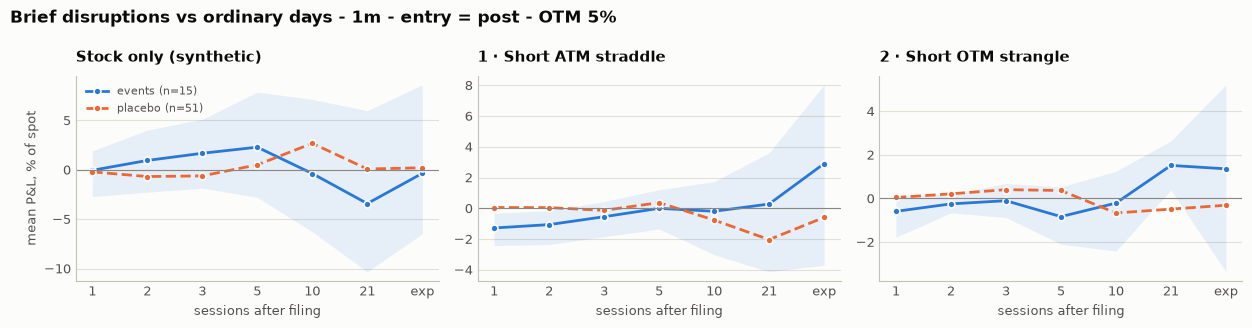

Events minus ordinary days, mean P&L per $1 spot. * = CI on the difference excludes zero.


,h=1,h=2,h=3,h=5,h=10,h=21,expiry
P&L per $1 spot,,,,,,,
Stock only (synthetic),+0.15%,+1.63%,+2.29%,+1.79%,-3.06%,-3.50%,-0.57%
1 · Short ATM straddle,-1.33%*,-1.10%*,-0.41%,-0.37%,+0.57%,+2.31%,+3.49%
2 · Short OTM strangle,-0.64%,-0.46%,-0.51%,-1.20%,+0.45%,+2.00%,+1.67%


In [11]:
def sample_placebo(ev: pd.DataFrame, n: int, start: str, end: str, gap_days: int = PLACEBO_GAP_DAYS, seed: int = 7) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    sessions = CAL[(CAL >= pd.Timestamp(start)) & (CAL <= pd.Timestamp(end))]
    if ev is None or len(ev) == 0 or len(sessions) == 0:
        return pd.DataFrame(columns=["ticker", "filing_date", "event_date", "t_0", "t_pre"])
    by_ticker = ev.groupby("ticker")["filing_date"].apply(list)
    rows = []
    for t in rng.choice(ev["ticker"].to_numpy(), size=n, replace=True):
        for _ in range(25):
            d = sessions[rng.integers(len(sessions))]
            if all(abs((d - a).days) > gap_days for a in by_ticker.get(t, [])):
                rows.append({"ticker": t, "filing_date": d, "event_date": d, "t_0": d, "t_pre": session_before(d)})
                break
    return pd.DataFrame(rows)


placebo_results = pd.DataFrame()
diff = pd.DataFrame()
if RUN_PLACEBO and len(events):
    placebo_events = sample_placebo(events, N_PLACEBO, STUDY_START, STUDY_END)
    placebo_priced, placebo_dropped = price_events(placebo_events, label="placebo")
    placebo_results = evaluate(placebo_priced)
    placebo_board = scoreboard(placebo_results)
    plot_scoreboards({"events": board, "placebo": placebo_board},
                     f"Brief disruptions vs ordinary days - {BASELINE_BUCKET} - entry = {ENTRY} - OTM {OTM_PCT:.0%}")
    diff = difference_board(results, placebo_results)
    print("Events minus ordinary days, mean P&L per $1 spot. * = CI on the difference excludes zero.")
    display(fmt_board(diff, value="difference"))
elif not RUN_PLACEBO:
    print("Placebo skipped (RUN_PLACEBO = False).")
else:
    print("No in-sample events - placebo skipped.")


### The in-sample answer

`rank_strategies` orders `STRUCTURES` by event-minus-placebo edge, averaged over the
21-session, 42-session and expiry horizons of the headline bucket.


In [12]:
def rank_strategies(diff: pd.DataFrame, horizons=(21, 42, "exp")) -> pd.DataFrame:
    d = diff[diff.horizon.isin(horizons) & (diff.strategy.isin(STRUCTURES))]
    if d is None or len(d) == 0 or "difference" not in d.columns:
        return pd.DataFrame()
    out = (d.groupby("strategy").agg(edge=("difference", "mean"),
                                     n_events=("n_a", "max"))
             .sort_values("edge", ascending=False))
    out["edge"] = out["edge"].map(lambda v: f"{v * 100:+.2f}%" if pd.notna(v) else "")
    return out.rename(index=STRATEGY_LABEL)


if RUN_PLACEBO and len(diff) and "difference" in diff.columns and diff["difference"].notna().any():
    ranking = rank_strategies(diff)
    display(ranking)
    WINNER = [k for k, v in STRATEGY_LABEL.items() if len(ranking) and v == ranking.index[0]][0] if len(ranking) else STRUCTURES[0]
    print(f"In-sample answer: after a FIRMS-brief disruption 8-K, the structure with the largest edge is "
          f"'{STRATEGY_LABEL[WINNER]}' ({BASELINE_BUCKET}, entry = {ENTRY}, OTM {OTM_PCT:.0%}).")
else:
    WINNER = STRUCTURES[0]
    print(f"Defaulting WINNER to {STRATEGY_LABEL[WINNER]} (no placebo ranking available).")


,edge,n_events
strategy,,
1 · Short ATM straddle,+2.90%,10
2 · Short OTM strangle,+1.84%,10


In-sample answer: after a FIRMS-brief disruption 8-K, the structure with the largest edge is '1 · Short ATM straddle' (1m, entry = post, OTM 5%).


### The yardstick: did the market price the event?

ATM-pair cost on `t_pre` / spot is the **implied move**; synthetic stock gives the
realized move. Ratio |realized| ÷ implied near 1 means the market was about right;
well below 1 at short horizons supports the sell-premium thesis.


In [13]:
def decay_table(r: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for h in [h for h in HORIZONS + ["exp"] if h in set(r.horizon)]:
        x = r.loc[r.horizon == h, "ratio"].dropna()
        lo, hi = bootstrap_ci(x)
        rows.append({"horizon": h, "n": len(x), "mean_ratio": x.mean() if len(x) else np.nan, "ci_lo": lo, "ci_hi": hi,
                     "median_ratio": x.median() if len(x) else np.nan,
                     "share_above_1": (x > 1).mean() if len(x) else np.nan})
    return pd.DataFrame(rows).set_index("horizon")


def fmt_decay(tbl: pd.DataFrame) -> pd.DataFrame:
    out = tbl.copy()
    for c in ["mean_ratio", "ci_lo", "ci_hi", "median_ratio"]:
        out[c] = out[c].map(lambda v: f"{v:.2f}" if pd.notna(v) else "")
    out["share_above_1"] = out["share_above_1"].map(lambda v: f"{v:.0%}" if pd.notna(v) else "")
    return out


if len(results):
    pre = slice_results(results, BASELINE_BUCKET, "pre", OTM_PCT)
    pre_exp = pre[pre.horizon == "exp"] if len(pre) else pre
    if len(pre_exp):
        print(f"{BASELINE_BUCKET} ATM pair on t_pre: median implied move {pre_exp.implied_move.median():.1%}, "
              f"median |realized| {pre_exp.realized.abs().median():.1%}; "
              f"realized beat implied in {(pre_exp.realized.abs() > pre_exp.implied_move).mean():.0%} of events")
    tables = {"events": decay_table(pre)}
    if RUN_PLACEBO and len(placebo_results):
        tables["placebo"] = decay_table(slice_results(placebo_results, BASELINE_BUCKET, "pre", OTM_PCT))
    display(fmt_decay(pd.concat(tables, names=["group", "horizon"])))
else:
    print("No results for decay table.")


1m ATM pair on t_pre: median implied move 11.5%, median |realized| 5.3%; realized beat implied in 13% of events


n mean_ratio ci_lo ci_hi median_ratio share_above_1
group   horizon                                                      
events  1        15       0.83  0.50  1.34         0.63           27%
        2        15       0.97  0.62  1.37         0.63           33%
        3        15       1.03  0.68  1.40         0.86           40%
        5        11       1.05  0.68  1.42         1.29           55%
        10       10       1.07  0.69  1.52         0.70           40%
        21        8       0.97  0.55  1.41         1.03           50%
        exp      10       0.74  0.33  1.29         0.59           20%
placebo 1        52       0.68  0.55  0.81         0.59           19%
        2        50       0.72  0.57  0.90         0.68           30%
        3        47       0.87  0.70  1.06         0.66           38%
        5        45       0.83  0.64  1.03         0.63           36%
        10       46       1.04  0.82  1.27         0.72           46%
        21       17       0.99  0.58  1.53         0.86           47%
        exp      43       0.98  0.74  1.25         0.93           42%

## 8 · Out-of-sample

Nothing above touched these dates. Same pipeline on `OOS_START`..`OOS_END`. Read
results with the (often small) sample size in view.


Loaded 45 cached disruption events from c:\Users\kprsa\Documents\CodingProjects\GQHacks\tracks\physical_facility_disruption\data\events\disruption_events.json
10 in universe/window -> 8 after trade_groups={'brief'}
8 out-of-sample events across 7 tickers


,ticker,filing_date,t_pre,t_0,facility_group,disruption_type,days_since_prev_event
0,AA,2025-09-30,2025-09-29,2025-09-30,brief,plant_shutdown,NaN
1,CE,2025-10-28,2025-10-27,2025-10-28,brief,plant_shutdown,NaN
2,DOW,2025-07-07,2025-07-03,2025-07-07,brief,plant_shutdown,NaN
3,FCX,2025-11-18,2025-11-17,2025-11-18,brief,plant_shutdown,NaN
4,INGR,2025-01-06,2025-01-03,2025-01-06,brief,physical_disruption,NaN
5,IP,2025-02-13,2025-02-12,2025-02-13,brief,plant_shutdown,NaN
6,IP,2025-08-21,2025-08-20,2025-08-21,brief,plant_shutdown,189.0
7,PBF,2025-03-06,2025-03-05,2025-03-06,brief,facility_fire,NaN


out-of-sample: 8 events -> 18 priced (event, bucket) pairs; 4 drops; 1s
Out-of-sample - 2025-01-01..2025-12-31 - 1m - entry = post - OTM 5% - n = 5


,h=1,h=2,h=3,h=5,h=10,h=21,expiry
P&L per $1 spot,,,,,,,
Stock only (synthetic),+3.43%*,+2.80%,+3.27%,+0.01%,+6.27%*,+9.45%,-3.06%
1 · Short ATM straddle,-1.54%*,-0.53%,-1.34%,-1.53%,+0.40%,-4.77%,-5.98%
2 · Short OTM strangle,-0.70%,-0.69%*,-0.03%,+0.07%,+1.98%,-4.24%,-3.31%


In-sample mean -> out-of-sample mean; OK = same sign.


,h=5,h=21,expiry
in -> out,,,
Stock only (synthetic),+2.29% -> +0.01% OK,-3.42% -> +9.45% X,-0.36% -> -3.06% OK
1 · Short ATM straddle,-0.00% -> -1.53% OK,+0.28% -> -4.77% X,+2.90% -> -5.98% X
2 · Short OTM strangle,-0.83% -> +0.07% X,+1.51% -> -4.24% X,+1.36% -> -3.31% X


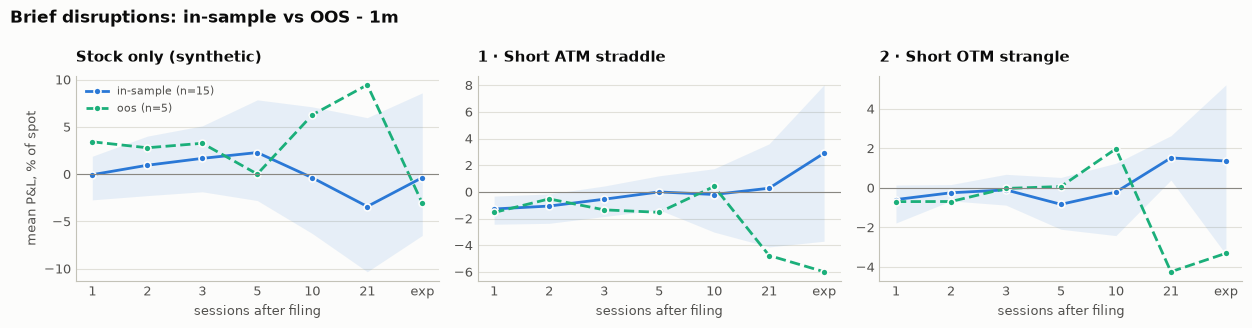

In [14]:
oos_events = build_events_from_cache(OOS_START, OOS_END, FACILITY_UNIVERSE)
print(f"{len(oos_events)} out-of-sample events across {oos_events.ticker.nunique() if len(oos_events) else 0} tickers")
if len(oos_events):
    cols = [c for c in ["ticker", "filing_date", "t_pre", "t_0", "facility_group", "disruption_type", "days_since_prev_event"] if c in oos_events.columns]
    display(oos_events[cols].reset_index(drop=True))
oos_priced, oos_dropped = price_events(oos_events, label="out-of-sample")
oos_results = evaluate(oos_priced)
oos_board = scoreboard(oos_results)
print(f"Out-of-sample - {OOS_START}..{OOS_END} - {BASELINE_BUCKET} - entry = {ENTRY} - OTM {OTM_PCT:.0%} - "
      f"n = {int(oos_board.n.max()) if len(oos_board) and oos_board.n.notna().any() else 0}")
display(fmt_board(oos_board))

if len(board) and len(oos_board):
    comparison = (board.merge(oos_board, on=["strategy", "horizon"], suffixes=("_in", "_oos"))
                       .assign(same_sign=lambda d: np.sign(d.mean_in) == np.sign(d.mean_oos)))
    comp = comparison[comparison.horizon.isin([5, 21, 42, "exp"])]
    if len(comp):
        comp_wide = (comp.assign(cell=lambda d: [f"{a * 100:+.2f}% -> {b * 100:+.2f}% {'OK' if s else 'X'}"
                                                for a, b, s in zip(d.mean_in, d.mean_oos, d.same_sign)])
                         .pivot(index="strategy", columns="horizon", values="cell")
                         .reindex(["stock"] + STRUCTURES).rename(index=STRATEGY_LABEL))
        comp_wide.columns = [f"h={c}" if c != "exp" else "expiry" for c in comp_wide.columns]
        print("In-sample mean -> out-of-sample mean; OK = same sign.")
        display(comp_wide.rename_axis("in -> out"))
    plot_scoreboards({"in-sample": board, "oos": oos_board},
                     f"Brief disruptions: in-sample vs OOS - {BASELINE_BUCKET}")


## 9 · One ticker, end to end

Among tickers with an out-of-sample event, pick the one with the most in-sample
events (ties broken by ATM volume). Lists real OCC symbols and the day-by-day path
of the winning structure.


Example ticker: CE - 3 in-sample brief disruption(s), 1 out-of-sample.


contract  strike  close at entry
sample        filing_date entry      expiry     spot at entry leg                                                     
in-sample     2020-07-28  2020-07-28 2020-08-21 92.36         ATM call     O:CE200821C00092500    92.5            3.90
                                                              ATM put      O:CE200821P00092500    92.5            3.80
                                                              call 5% OTM  O:CE200821C00100000   100.0            1.62
                                                              put 5% OTM   O:CE200821P00087500    87.5            2.65
out-of-sample 2025-10-28  2025-10-28 2025-11-21 41.97         ATM call     O:CE251121C00045000    45.0            2.65
                                                              ATM put      O:CE251121P00045000    45.0            5.56
                                                              call 5% OTM  O:CE251121C00050000    50.0            1.20
                                                              put 5% OTM   O:CE251121P00040000    40.0            3.10

realized 1 · Short ATM straddle  \
sample        filing     horizon                                   
in-sample     2020-07-28 5          +4.5%                  +1.0%   
                         exp                                       
out-of-sample 2025-10-28 5         -11.1%                  -3.7%   
                         exp        -8.9%                  +3.2%   

                                 2 · Short OTM strangle  
sample        filing     horizon                         
in-sample     2020-07-28 5                        +1.6%  
                         exp                             
out-of-sample 2025-10-28 5                        -3.2%  
                         exp                      +5.6%

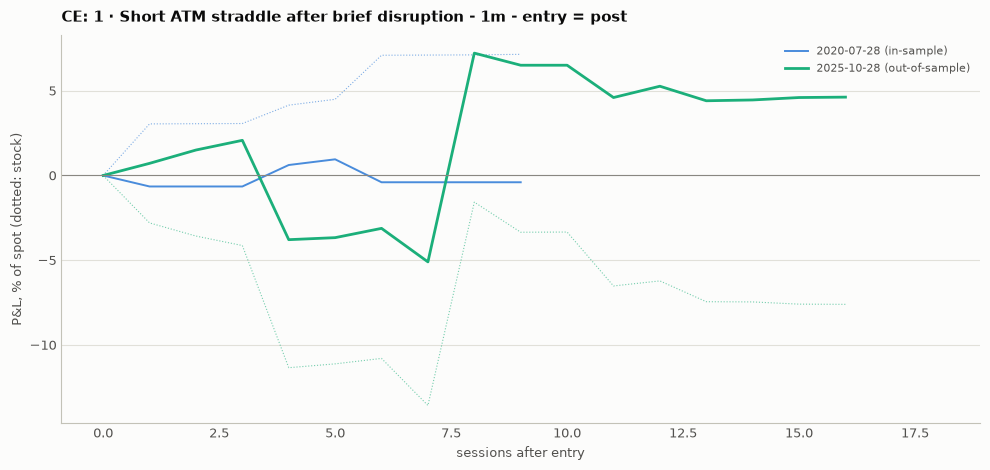

In [15]:
if len(events) == 0:
    print("No in-sample events to illustrate.")
    EXAMPLE = None
else:
    in_counts = events.ticker.value_counts()
    cands = [t for t in (oos_events.ticker.unique() if len(oos_events) else []) if t in in_counts.index]
    vol = panel.groupby("ticker")["atm_volume"].median() if len(panel) else pd.Series(dtype=float)
    if not cands:
        print("No ticker spans both windows; showing the busiest in-sample name.")
        cands = list(in_counts.index)
    EXAMPLE = sorted(cands, key=lambda t: (in_counts[t], vol.get(t, 0)), reverse=True)[0]
    print(f"Example ticker: {EXAMPLE} - {in_counts[EXAMPLE]} in-sample brief disruption(s), "
          f"{(oos_events.ticker == EXAMPLE).sum() if len(oos_events) else 0} out-of-sample.")

    ex_priced = [pe for pe in priced + oos_priced if pe.ticker == EXAMPLE and pe.bucket == BASELINE_BUCKET]
    ex_rows = []
    for pe in ex_priced:
        sample = "in-sample" if pe.event_date <= pd.Timestamp(STUDY_END) else "out-of-sample"
        m = pe.marks(pe.t_0)
        for name, key in [("ATM call", "C_K"), ("ATM put", "P_K"),
                          (f"call {OTM_PCT:.0%} OTM", f"C_U{OTM_PCT}"),
                          (f"put {OTM_PCT:.0%} OTM", f"P_L{OTM_PCT}")]:
            ex_rows.append({"sample": sample, "filing_date": pe.event_date.date(), "entry": pe.t_0.date(),
                            "expiry": pe.expiry.date(), "spot at entry": round(pe.synthetic_spot(pe.t_0, m), 2),
                            "leg": name, "contract": pe.legs[key].ticker, "strike": pe.legs[key].strike,
                            "close at entry": m[key]})
    if ex_rows:
        with pd.option_context("display.max_colwidth", 30, "display.width", 200):
            display(pd.DataFrame(ex_rows).set_index(["sample", "filing_date", "entry", "expiry", "spot at entry", "leg"]))

    if len(results) or len(oos_results):
        ex_res = pd.concat([results, oos_results], ignore_index=True) if len(oos_results) else results.copy()
        ex_res = ex_res[(ex_res.ticker == EXAMPLE) & (ex_res.bucket == BASELINE_BUCKET) &
                        (ex_res.entry == ENTRY) & (ex_res.otm == OTM_PCT)]
        if len(ex_res):
            ex_tbl = (ex_res[ex_res.horizon.isin([5, 21, 42, "exp"])]
                      .assign(sample=lambda d: np.where(d.event_date <= pd.Timestamp(STUDY_END), "in-sample", "out-of-sample"),
                              filing=lambda d: d.event_date.dt.date)
                      .set_index(["sample", "filing", "horizon"])[["realized"] + STRUCTURES]
                      .rename(columns=STRATEGY_LABEL).map(lambda v: f"{v * 100:+.1f}%" if pd.notna(v) else ""))
            display(ex_tbl)

    def pnl_path(pe: PricedEvent, strategy: str, entry: str = ENTRY, otm: float = OTM_PCT) -> pd.Series:
        e_day = pe.t_pre if entry == "pre" else pe.t_0
        m_e = pe.marks(e_day)
        S_e = pe.synthetic_spot(e_day, m_e)
        days = CAL[(CAL >= e_day) & (CAL <= min(pe.expiry_session, LAST_SESSION))]
        out = {}
        for d in days:
            m = pe.marks(d)
            out[sessions_between(e_day, d)] = strategy_pnl(m_e, m, S_e, pe.synthetic_spot(d, m), otm)[strategy]
        return pd.Series(out, name=f"{pe.event_date.date()}")

    if ex_priced:
        fig, ax = plt.subplots(figsize=(10, 4.8))
        for pe in ex_priced:
            sample = "in-sample" if pe.event_date <= pd.Timestamp(STUDY_END) else "oos"
            path = pnl_path(pe, WINNER)
            ax.plot(path.index, path.to_numpy() * 100, color=SERIES[sample], linewidth=2 if sample == "oos" else 1.4,
                    alpha=1 if sample == "oos" else 0.85,
                    label=f"{pe.event_date.date()} ({'out-of-sample' if sample == 'oos' else 'in-sample'})")
            ax.plot(path.index, pnl_path(pe, "stock").to_numpy() * 100, color=SERIES[sample],
                    linewidth=0.8, linestyle=":", alpha=0.6)
        ax.axhline(0, color=MUTED, linewidth=0.8)
        style(ax, f"{EXAMPLE}: {STRATEGY_LABEL[WINNER]} after brief disruption - {BASELINE_BUCKET} - entry = {ENTRY}",
              "sessions after entry", "P&L, % of spot (dotted: stock)")
        ax.legend(frameon=False, labelcolor=INK2, fontsize=8)
        plt.tight_layout()
        plt.show()


## 10 · Parameter sensitivity

A finding that lives at one parameter setting is not a finding. Grid: OTM distance,
and expiry bucket crossed with entry session, for the structures in `STRUCTURES`.


In [16]:
SENS_HORIZON = 21
grid_rows = []
if len(results):
    for b in EXPIRY_BUCKETS:
        for e in ("pre", "post"):
            for o in OTM_GRID:
                sb = scoreboard(results, bucket=b, entry=e, otm=o, horizons=[SENS_HORIZON],
                                strategies=STRUCTURES)
                for _, r in sb.iterrows():
                    grid_rows.append({"bucket": b, "entry": e, "otm": o, "strategy": r.strategy,
                                      "n": r.n, "mean": r["mean"], "ci_lo": r.ci_lo, "ci_hi": r.ci_hi})
grid = pd.DataFrame(grid_rows)
if len(grid):
    grid["cell"] = [f"{m * 100:+.2f}%{'*' if pd.notna(lo) and (lo > 0 or hi < 0) else ''}" if pd.notna(m) else ""
                    for m, lo, hi in zip(grid["mean"], grid.ci_lo, grid.ci_hi)]

    def sens_table(sub: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
        return (sub.pivot_table(index="strategy", columns=columns, values="cell", aggfunc="first")
                  .reindex(STRUCTURES).rename(index=STRATEGY_LABEL)
                  .rename_axis(f"mean P&L at h={SENS_HORIZON}", axis=0))

    print(f"1 - Vary OTM, holding {BASELINE_BUCKET} (in-sample, h={SENS_HORIZON}):")
    display(sens_table(grid[grid.bucket == BASELINE_BUCKET], ["entry", "otm"]))
    print(f"2 - Vary expiry bucket and entry, holding OTM = {OTM_PCT:.0%}:")
    display(sens_table(grid[grid.otm == OTM_PCT], ["entry", "bucket"]))
else:
    print("No results for sensitivity grid.")


1 - Vary OTM, holding 1m (in-sample, h=21):


entry                      post                        pre                  
otm                        0.03     0.05     0.10     0.03     0.05     0.10
mean P&L at h=21                                                            
1 · Short ATM straddle   +0.28%   +0.28%   +0.28%   +0.81%   +0.81%   +0.81%
2 · Short OTM strangle  +2.50%*  +1.51%*  +2.33%*  +2.20%*  +1.52%*  +2.30%*

2 - Vary expiry bucket and entry, holding OTM = 5%:


entry                      post                      pre                
bucket                       1m      2m    3-6m       1m      2m    3-6m
mean P&L at h=21                                                        
1 · Short ATM straddle   +0.28%  -0.95%  -0.41%   +0.81%  -0.33%  -0.38%
2 · Short OTM strangle  +1.51%*  -2.75%  -0.37%  +1.52%*  -2.34%  -0.83%

## 11 · Specifying the trade (scored on realism, not P&L)

If the finding is real, say how you would trade it and what it would cost:

- **Instrument and entry**: short straddle (default) or OTM strangle, `1m` bucket, fill at close of
  `t_0` (`ENTRY="post"`).
- **Exit**: fixed horizon (e.g. 21 sessions) or expiry — justify from the decay table.
- **Costs**: haircut below is a stand-in until you have quotes.


In [17]:
COST_HAIRCUT = 0.05

if len(results) and len(priced):
    hz = slice_results(results, BASELINE_BUCKET, ENTRY, OTM_PCT)
    exp_rows = hz[hz.horizon == 21].copy()
    legs_used = {
        "short_atm_straddle": ["C_K", "P_K"],
        "short_otm_strangle": [f"C_U{OTM_PCT}", f"P_L{OTM_PCT}"],
        "short_atm_put": ["P_K"],
        "long_call": ["C_K"],
        "covered_call": [f"C_U{OTM_PCT}"],
        "protective_put": [f"P_L{OTM_PCT}"],
        "collar": [f"C_U{OTM_PCT}", f"P_L{OTM_PCT}"],
        "cash_secured_put": [f"P_L{OTM_PCT}"],
    }
    prem = {(pe.ticker, pe.event_date): pe.marks(pe.t_0) for pe in priced if pe.bucket == BASELINE_BUCKET}
    vols = {(pe.ticker, pe.event_date): sum(pe.legs[l].volume_on(pe.t_0) for l in legs_used[WINNER])
            for pe in priced if pe.bucket == BASELINE_BUCKET}
    if len(exp_rows):
        exp_rows["premium_traded"] = [
            sum(abs(prem[(t, d)][l]) for l in legs_used[WINNER]) / s
            for t, d, s in zip(exp_rows.ticker, exp_rows.event_date, exp_rows.S_entry)
        ]
        exp_rows["cost"] = exp_rows["premium_traded"] * COST_HAIRCUT * 2
        exp_rows["net"] = exp_rows[WINNER] - exp_rows["cost"]
        exp_rows["leg_volume"] = [vols[(t, d)] for t, d in zip(exp_rows.ticker, exp_rows.event_date)]
        summary = pd.Series({
            "strategy": STRATEGY_LABEL[WINNER],
            "events": f"{len(exp_rows)}",
            "gross mean P&L at h=21, per $1 spot": f"{exp_rows[WINNER].mean() * 100:+.2f}%",
            f"mean round-trip cost ({COST_HAIRCUT:.0%} of premium each way)": f"{exp_rows['cost'].mean() * 100:.2f}%",
            "net mean P&L at h=21": f"{exp_rows['net'].mean() * 100:+.2f}%",
            "share of events net positive": f"{(exp_rows['net'] > 0).mean():.0%}",
            "median contracts traded in the option legs on the filing session": f"{exp_rows['leg_volume'].median():,.0f}",
        })
        display(summary.to_frame("value"))
    else:
        print("No h=21 rows for cost haircut.")
else:
    print("Skipped - need priced in-sample events.")


,value
strategy,1 · Short ATM straddle
events,9
"gross mean P&L at h=21, per $1 spot",+0.28%
mean round-trip cost (5% of premium each way),1.09%
net mean P&L at h=21,-0.66%
share of events net positive,44%
median contracts traded in the option legs on the filing session,24


## Stretch · FIRMS `persist_days` sensitivity

Instead of scraping EDGAR acceptance times, vary the brief/persistent threshold.
Re-label cached events at `persist_days ∈ {2, 3, 5}`, rebuild the tradeable set, and
compare event counts (full OPRA re-price is optional and slow — counts alone show
how fragile the treatment arm is).


In [18]:
persist_rows = []
_raw_all = load_cached_events(EVENTS_PATH)
for pdays in (2, 3, 5):
    if _raw_all.empty:
        break
    labeled = _raw_all.copy()
    labeled["facility_group"] = [
        assign_facility_group(
            anomaly_detected=row.get("anomaly_detected"),
            anomaly_persist_days=row.get("anomaly_persist_days"),
            persist_days=pdays,
            has_site=bool(row.get("has_site", row.get("site_lat") is not None)),
            has_satellite_coverage=bool(row.get("has_satellite_coverage", True)),
        )
        for row in labeled.to_dict("records")
    ]
    win = labeled[(labeled.filing_date >= pd.Timestamp(STUDY_START)) &
                  (labeled.filing_date <= pd.Timestamp(STUDY_END)) &
                  (labeled.ticker.isin(FACILITY_UNIVERSE))]
    counts = win.facility_group.value_counts()
    persist_rows.append({
        "persist_days": pdays,
        "brief": int(counts.get("brief", 0)),
        "persistent": int(counts.get("persistent", 0)),
        "unknown": int(counts.get("unknown", 0)),
        "tradeable": int(counts.get("brief", 0)) if "brief" in TRADE_GROUPS else 0,
    })
display(pd.DataFrame(persist_rows).set_index("persist_days"))
print("Full re-price at each threshold is left as an exercise - flip PERSIST_DAYS in section 2 and rerun from section 4.")


,brief,persistent,unknown,tradeable
persist_days,,,,
2,24,1,6,24
3,24,1,6,24
5,25,0,6,25


Full re-price at each threshold is left as an exercise - flip PERSIST_DAYS in section 2 and rerun from section 4.


## Sealed window · judges only

`run_study(start, end, universe)` is **tag-free**: it loads disruption events for the
window, prices chains, and returns the scoreboard. Judges set `RUN_HOLDOUT = True`
and the sealed dates in section 2.


In [19]:
def run_study(start: str, end: str, universe: list[str] | None = None, buckets: dict = None,
              max_events: int | None = None, label: str = None,
              trade_groups: set[str] | None = None) -> dict:
    """Whole pipeline on a fresh window - no EVENT_TAG. Returns events, priced, results, board."""
    universe = universe or FACILITY_UNIVERSE
    buckets = buckets or EXPIRY_BUCKETS
    ev = build_events_from_cache(start, end, universe, trade_groups=trade_groups)
    if max_events:
        ev = ev.head(max_events).copy()
    pr, drops = price_events(ev, buckets, label=label or f"disruption {start}..{end}")
    res = evaluate(pr)
    return {"events": ev, "priced": pr, "dropped": drops, "results": res, "board": scoreboard(res)}


if RUN_HOLDOUT:
    holdout = run_study(HOLDOUT_START, HOLDOUT_END)
    n = int(holdout["board"].n.max()) if len(holdout["board"]) and holdout["board"].n.notna().any() else 0
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END}: n = {n}.")
    display(fmt_board(holdout["board"]))
    if len(board) and len(holdout["board"]):
        plot_scoreboards({"in-sample": board, "oos": holdout["board"]},
                         f"Brief disruptions: in-sample vs sealed {HOLDOUT_START}..{HOLDOUT_END} - {BASELINE_BUCKET}")
else:
    print(f"Sealed window {HOLDOUT_START}..{HOLDOUT_END} not run. Judges: set RUN_HOLDOUT = True.")


Sealed window 2026-01-01..2026-06-30 not run. Judges: set RUN_HOLDOUT = True.


## Appendix · Known limitations you should mention in your write-up

- **FIRMS wildfire bias.** NASA FIRMS is tuned for wildfires; industrial heat can be
  missed or misclassified. Brief vs persistent labels are noisy.
- **Geocode is city-level.** Nominatim sites are not exact plant footprints — a hotspot
  a few km away may be the wrong facility or an unrelated fire.
- **Small sample.** True disruption 8-Ks in a liquid options nameset are rare. Treat
  intervals and OOS as exploratory, not definitive.
- **OPRA vs synthetic.** This notebook marks real OPRA chains (Massive aggregates). The
  track's Webull/Backtrader path uses *synthetic* Black–Scholes marks — good for
  hypothesis tests, not fill realism. Do not conflate the two engines in the write-up.
- **Static universe.** `FACILITY_UNIVERSE` is a hand-picked industrial list, not a
  point-in-time index membership — survivorship and selection bias apply.
- **Put-call parity spot.** Flat `RISK_FREE`, no dividend term; last trades can be stale
  up to `MAX_STALE_SESSIONS`.
- **Cached events.** Default path does not re-query FIRMS. Refresh with the track
  scripts + `FIRMS_MAP_KEY` before claiming live satellite coverage.
- **Short-straddle risk.** Unlimited unilateral losses; marks ignore margin and gap opens. A defined-risk iron fly is the production cousin of this test.
